In [25]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

/home/nichettg/Ubuntu/Laboratorio/funzioni.py:253: SyntaxWarning: invalid escape sequence '\s'
  """


# 1. Lettura Dati

In [26]:
def nome (stringa):
    
    stringa_nuova = stringa.replace(f'./Data/Results_','').replace('.csv','')
    return stringa_nuova

In [27]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data = {}

for input_file in input_files:
    letti = pd.read_csv(input_file)
    data[nome(input_file)] = {}


    for key in letti.keys():
        colonna = letti[key]
        try:
            # prova a convertirla in float
            data[nome(input_file)][key] = colonna.astype(float).to_numpy()
        except ValueError:
            # se non ci riesce, tieni le stringhe
            data[nome(input_file)][key] = colonna.astype(str).to_list()

# 2. Analisi Dati

Viene stimato l'errore dovuto al riposizionamento del fascio laser al centro della CCD.
$$
semidisp = \frac{\max(x) - \min(x)}{2}
$$

$$
dev = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} (x_i - \overline{x})^2}
$$
Viene scelto uno solo dei due valori. Per sapere quale dei due viene usato nella run corrente del codice vedere sotto la seguente cella.


In [28]:
x = data["punto6"]["intensita"]
deviazione_standard = f.dev(x)
semidispersione_massima = f.semidisp(x)

err = deviazione_standard
stringa = "deviazione_standard"
print(f"Come errore viene scelta la {stringa.replace("_"," ")}")

del x,deviazione_standard,semidispersione_massima

Come errore viene scelta la deviazione standard


Vengono fatti i fit parabolici riguardanti i dati presi dal polarizzatore 1, polarizzatore 2 e dalla lente lambda mezzi. Per il fit si minimizza il seguente $\chi^2$:
$$
\sum_{i=1}^{N} \left( \frac{y_i - \left(a x_i^2 + b x_i + c\right)}{\sigma_{y_i}} \right)^2
$$
Come incertezza $\sigma_{y_i}$ viene usata la seguente formula:

$$
\sigma_{y_i} = \sqrt{{err_{pos}}^2 + {err_{int}}^2}
$$

dove con $err_{pos}$ si intende l'errore dato dal posizionamento del laser al centro della CCD e con $err_{int}$ si intende l'errore dato dalle fluttuazioni dell'intensità del laser.
Il primo è stato stimato nella cella precedente a partide dal punto 6 delle domande mentre il secondo viene stimato come il $5%$ del valore dell'intensità $I_i$ (gli errori saranno quindi non uniformi ma variabili in funzione di $I_i$).


In [29]:
from scipy.optimize import minimize
from scipy import odr

Fit polarizzatore 1
	a = -2610 ± 20 
	b = -15681 ± 700 
	c = 18597550 ± 30000 

Fit polarizzatore 2
	a = -2467 ± 40 
	b = 22465 ± 1000 
	c = 16402266 ± 50000 

Fit lambda_mezzi
	a = -9728 ± 200 
	b = 1043749 ± 20000 
	c = -11812866 ± 300000 



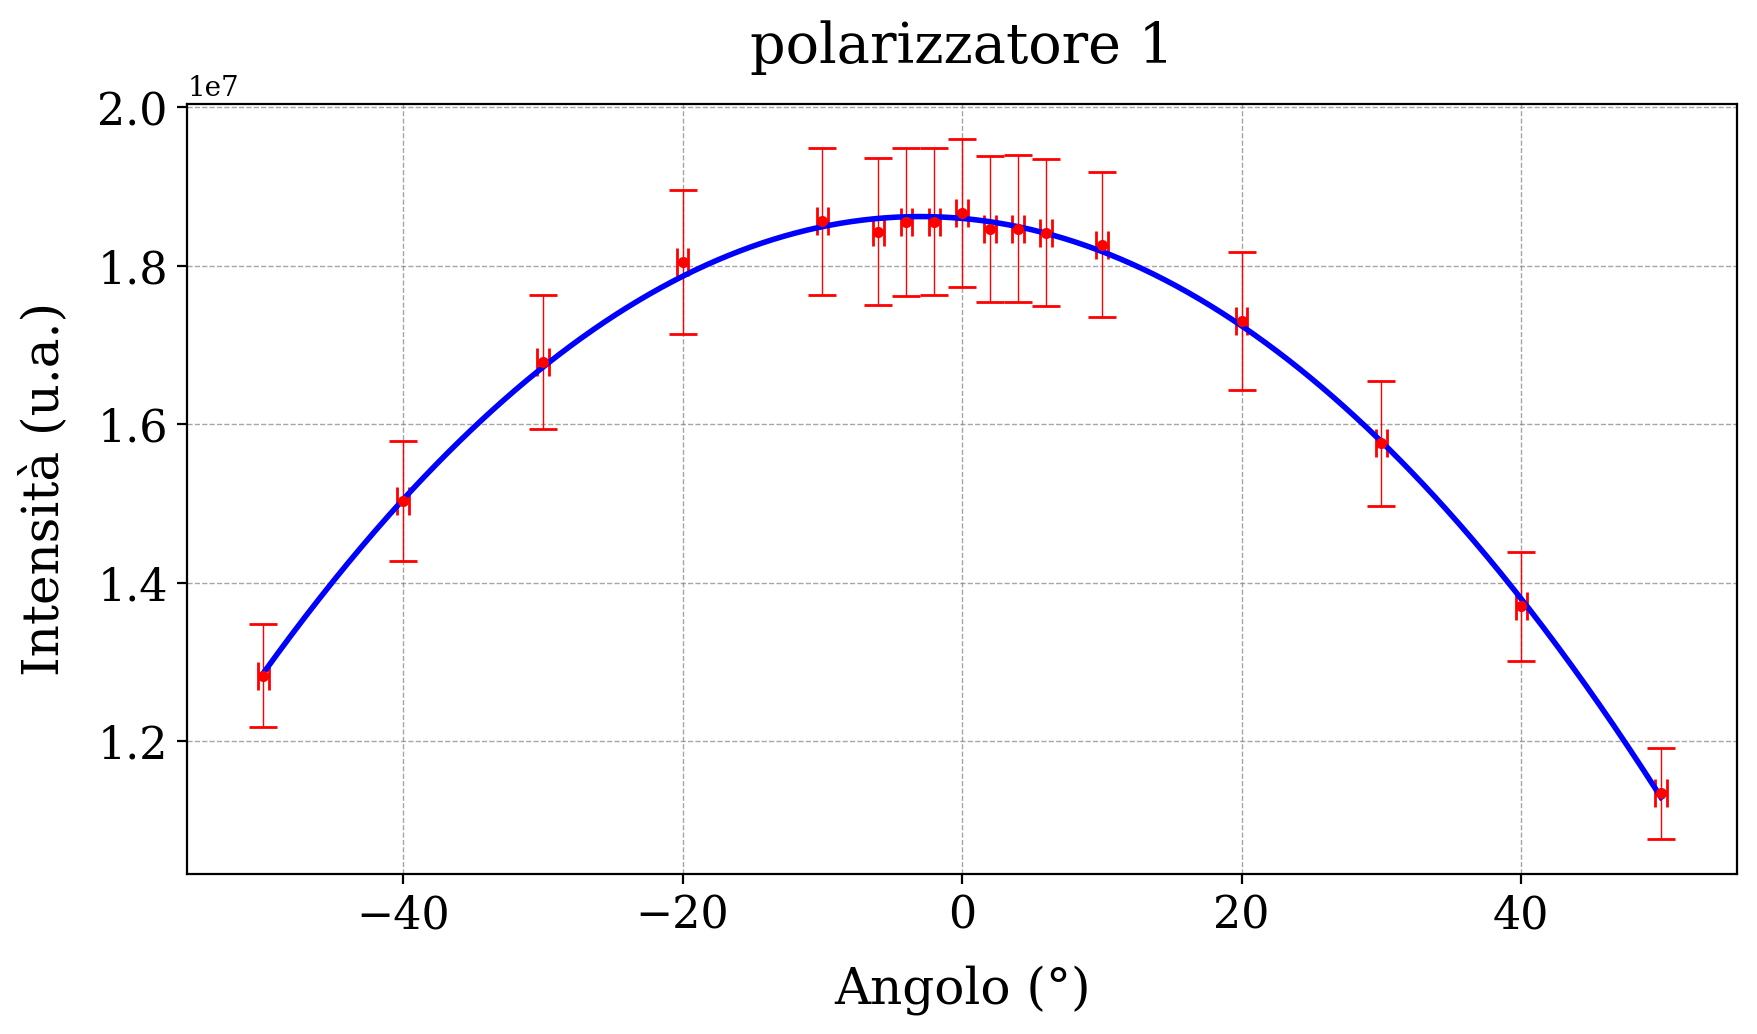

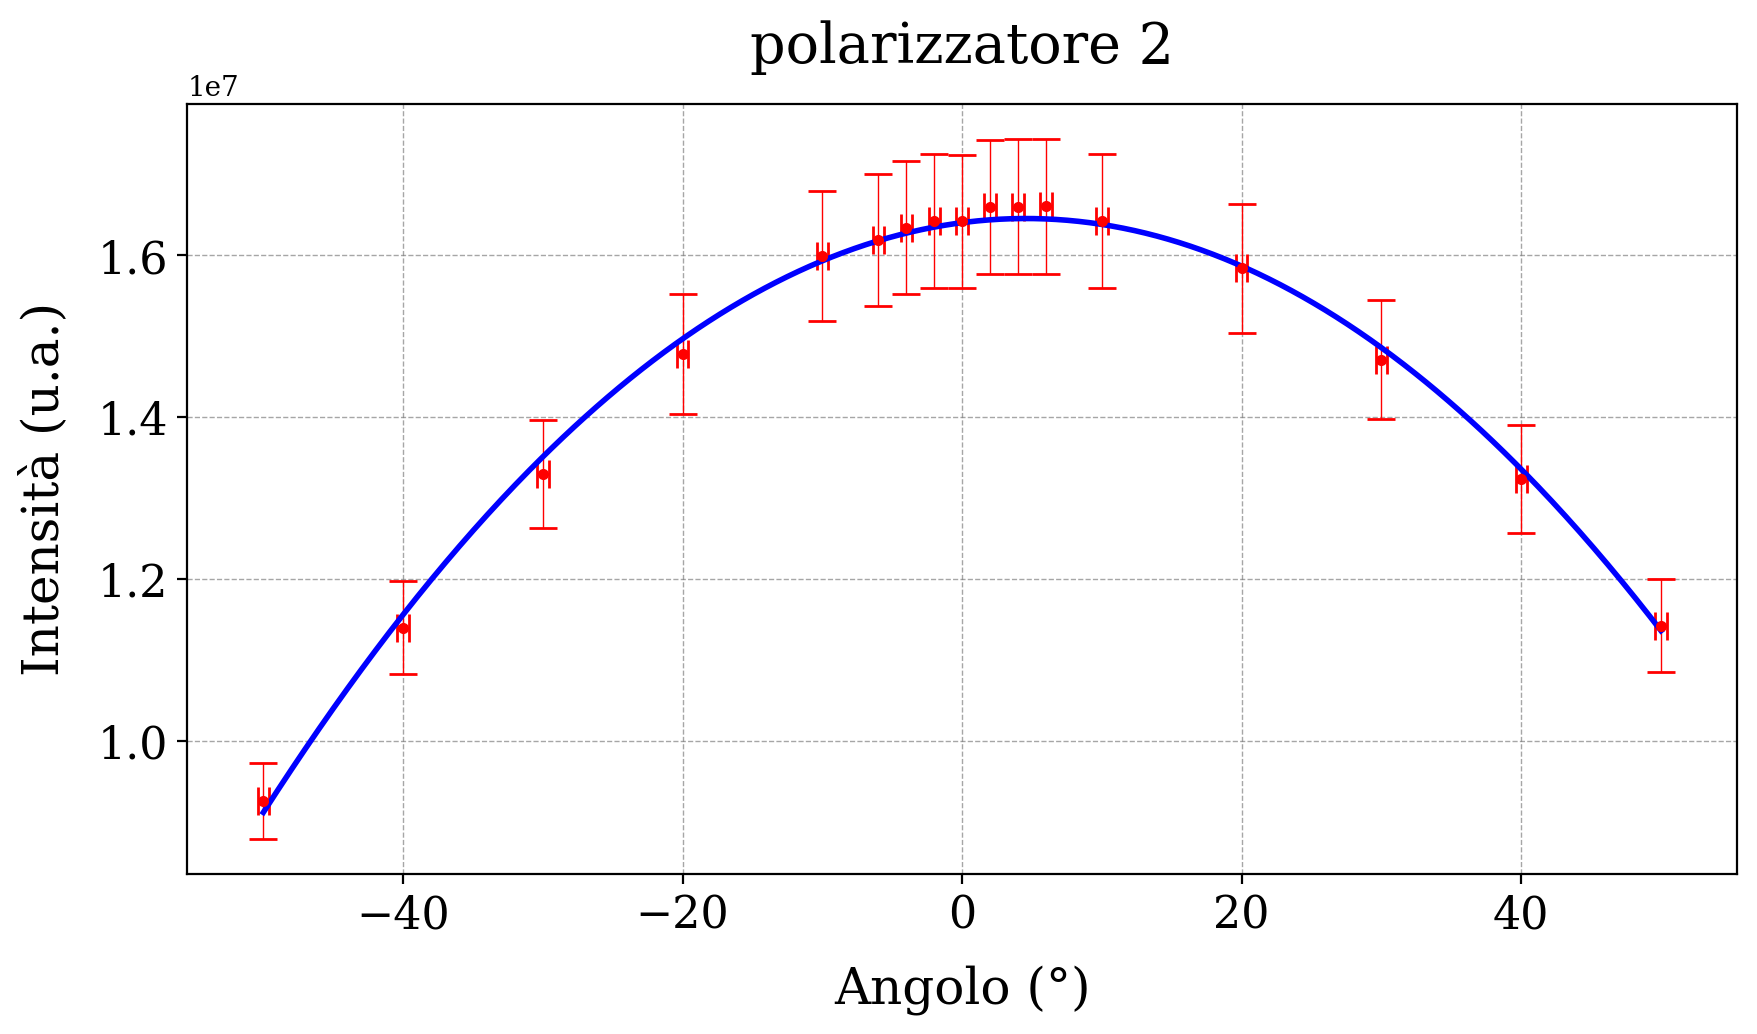

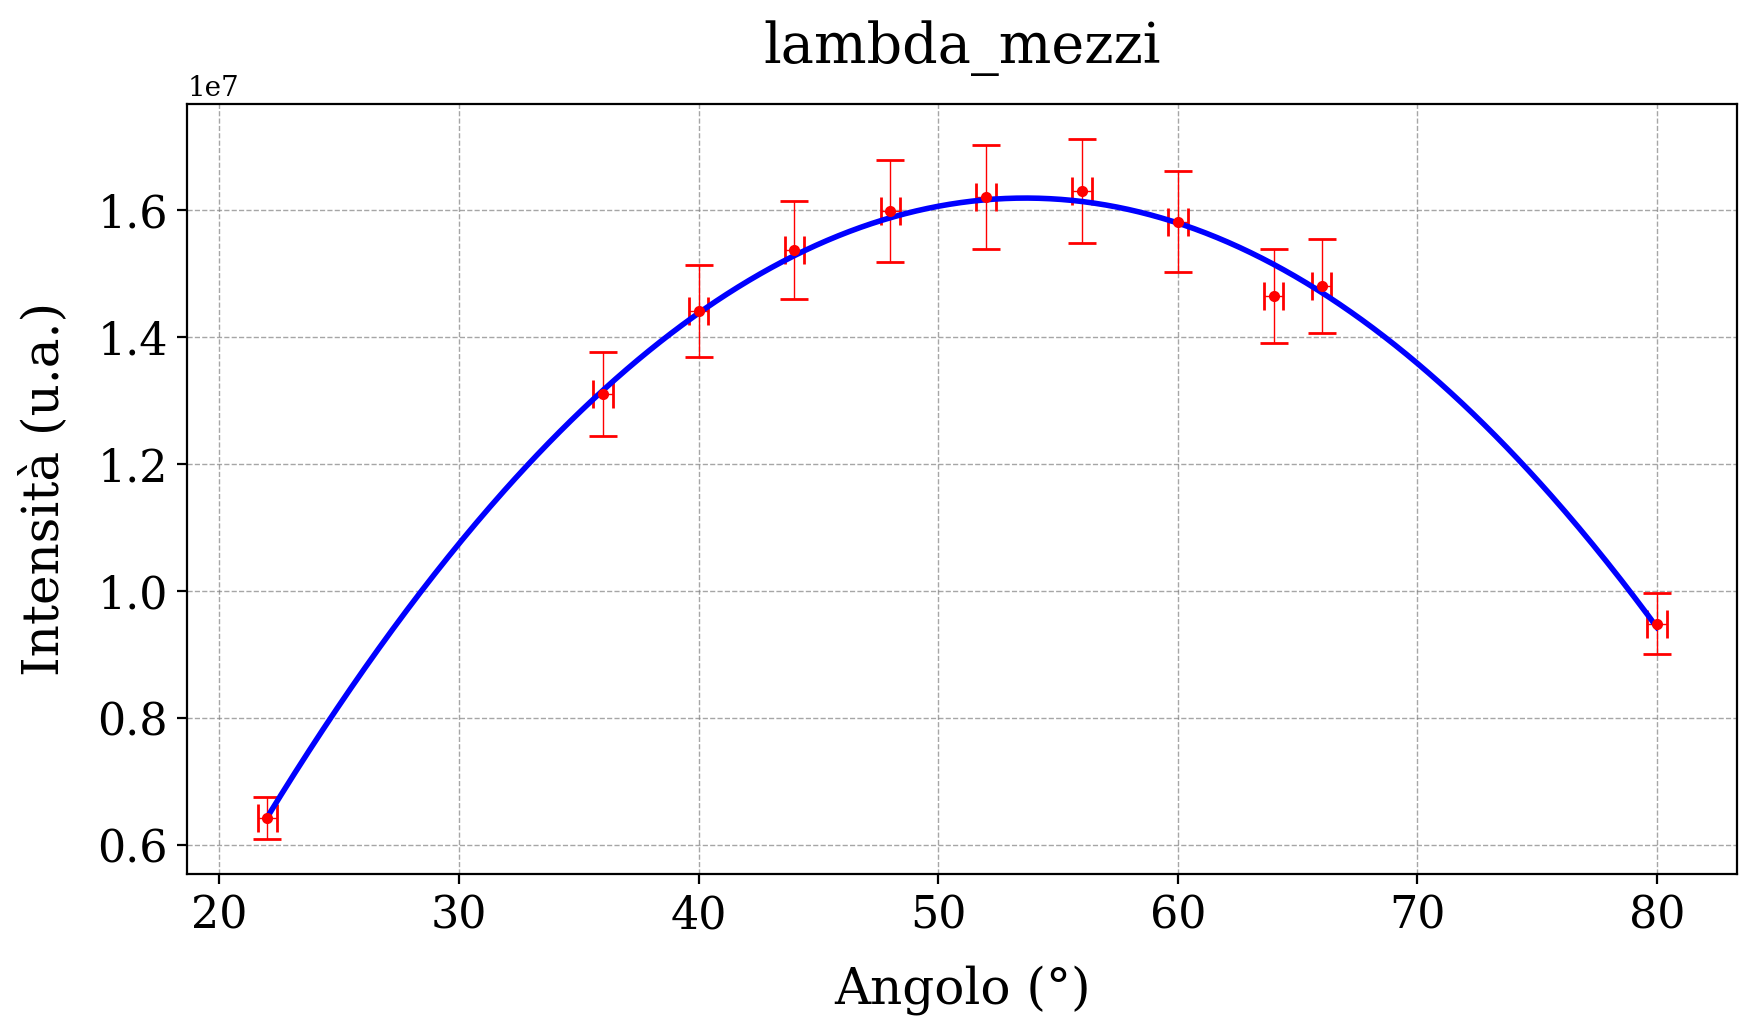

In [53]:
polarizzatori = {"polarizzatore 1" : data["punto9"],
        "polarizzatore 2": data["punto12"],
        "lambda_mezzi" : data["lambdamezzi"]}

for titolo,dati in polarizzatori.items():
    fig,ax = plt.subplots(1, 1,  figsize=(10, 5))


    # ------------------ Sezione 1: Dati ---------------------------
    # Vengono assegnate le incertezze ai dati per poi graficarli

    xdata = [dati["angolo"],
             np.full_like(dati["angolo"],2/np.sqrt(24))]
    ydata = [dati["intensita"],
             np.sqrt( err**2 + (0.05*dati["intensita"])**2 )]
    gf.parametri_grafico(ax,titolo,xlabel="Angolo (°)",ylabel="Intensità (u.a.)")
    ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())



    # ------------------ Sezione 2: Fit Parabolico ------------------
    # Viene fatto un fit tramite minimizzazione del Chi Quadro e
    # tramite routine ODR

    def parabola(B, x):
        (a, b, c) = B
        return a*x**2 + b*x + c
    x = xdata[0]
    y = ydata[0]
    a0 = - (np.max(y) - np.min(y)) / (np.max(x) - np.min(x))**2
    beta0 = [a0,
            -2 * a0 * np.mean(x),
            np.mean(y)]
    anal = f.fit(xdata,ydata,parabola,beta0, chi=False)

    print(f"Fit {titolo}")
    print(f"\ta = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
    print(f"\tb = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}")
    print(f"\tc = {gf.formatta_errore(anal[2][0],anal[2][1],txt=True)}\n")
    x = np.linspace(np.min(xdata[0]), np.max(xdata[0]), 500)
    y = parabola([anal[0][0], anal[1][0], anal[2][0]], x)
    ax.plot(x, y, color="blue")

    del xdata,ydata,x,y

Vengono graficati i dati relativi alla lente lambda quarti (le incertezze sono stimate con gli stessi criteri definiti in precedenza, quindi come somma quadratica dell'errore di riposizionamento del laser e della fluttuazione dell'intensità del laser). Viene anche graficata, come confronto, la media come linea orizzontale affiancata ad altre due rette poste a una deviazione standard dalla media. Tale deviazione standard viene calcolata con la formula seguente:
$$
dev = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} (I_i - \overline{I})^2}
$$
in cui $I_i$ rappresenta il campione delle intensità e $\overline{I}$ la sua media.

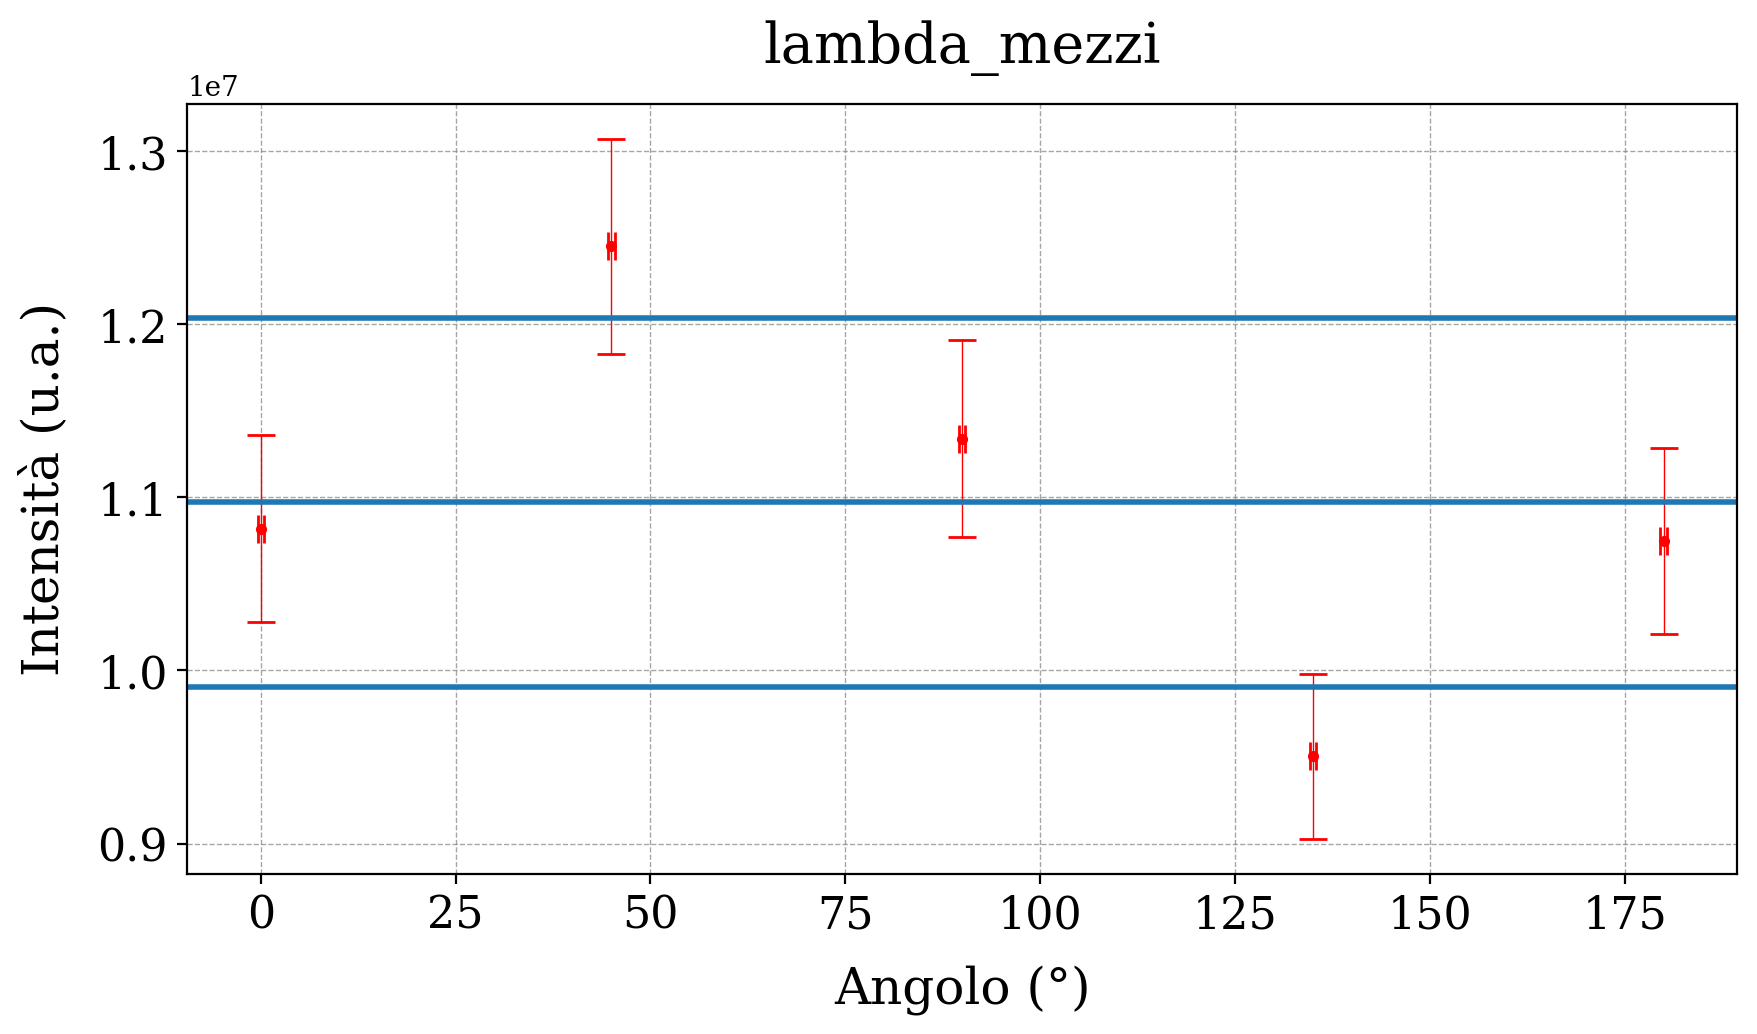

In [16]:
dati = data["lambdaquarti"]
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
xdata = [dati["angolo"],
         np.full_like(dati["angolo"],2/np.sqrt(24))]
ydata = [dati["intensita"],
         np.sqrt( err*2 + (0.05*dati["intensita"])**2 )]
gf.parametri_grafico(ax,titolo,xlabel="Angolo (°)",ylabel="Intensità (u.a.)")
ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

media = np.mean(ydata[0])
deviazione = f.dev(ydata[0])
for quota in [deviazione,0,-deviazione]:
    ax.axhline(y=media + quota)

Per il fit dei dati (con le stesse incertezze definite in precedenza) al fine di verifica della legge di Malus è stata usata la seguente legge (dopo aver trasformato gli angoli in gradi in radianti):
$$
I(\theta) = I_0 \cos^2(\theta - \theta_0) + I_{\mathrm{bg}}
$$

dove:
- $I(\theta)$ è l’intensità misurata;
- $I_0$ è l’ampiezza, ovvero l’intensità massima modulata dal polarizzatore;
- $\theta_0$ è l’angolo di disallineamento tra polarizzatore e analizzatore;
- $I_{\mathrm{bg}}$ è l’offset di fondo, che tiene conto della luce parassita e del rumore del rivelatore.

Il fit (come al solito) è fatto minimizzando un $\chi^2$ in cui quindi viene usata la seguente formula:
$$
\chi^2(I_0,\theta_0,I_{\mathrm{bg}}) =
\sum_{i=1}^{N}
\left[
\frac{
I_i - \left( I_0 \cos^2(\theta_i - \theta_0) + I_{\mathrm{bg}} \right)
}{
\sigma_i
}
\right]^2
$$


Fit lambda_mezzi
	A = 13973764 ± 10 
	B = 0.152 ± 0.009 
	C = 3552095 ± 60000 



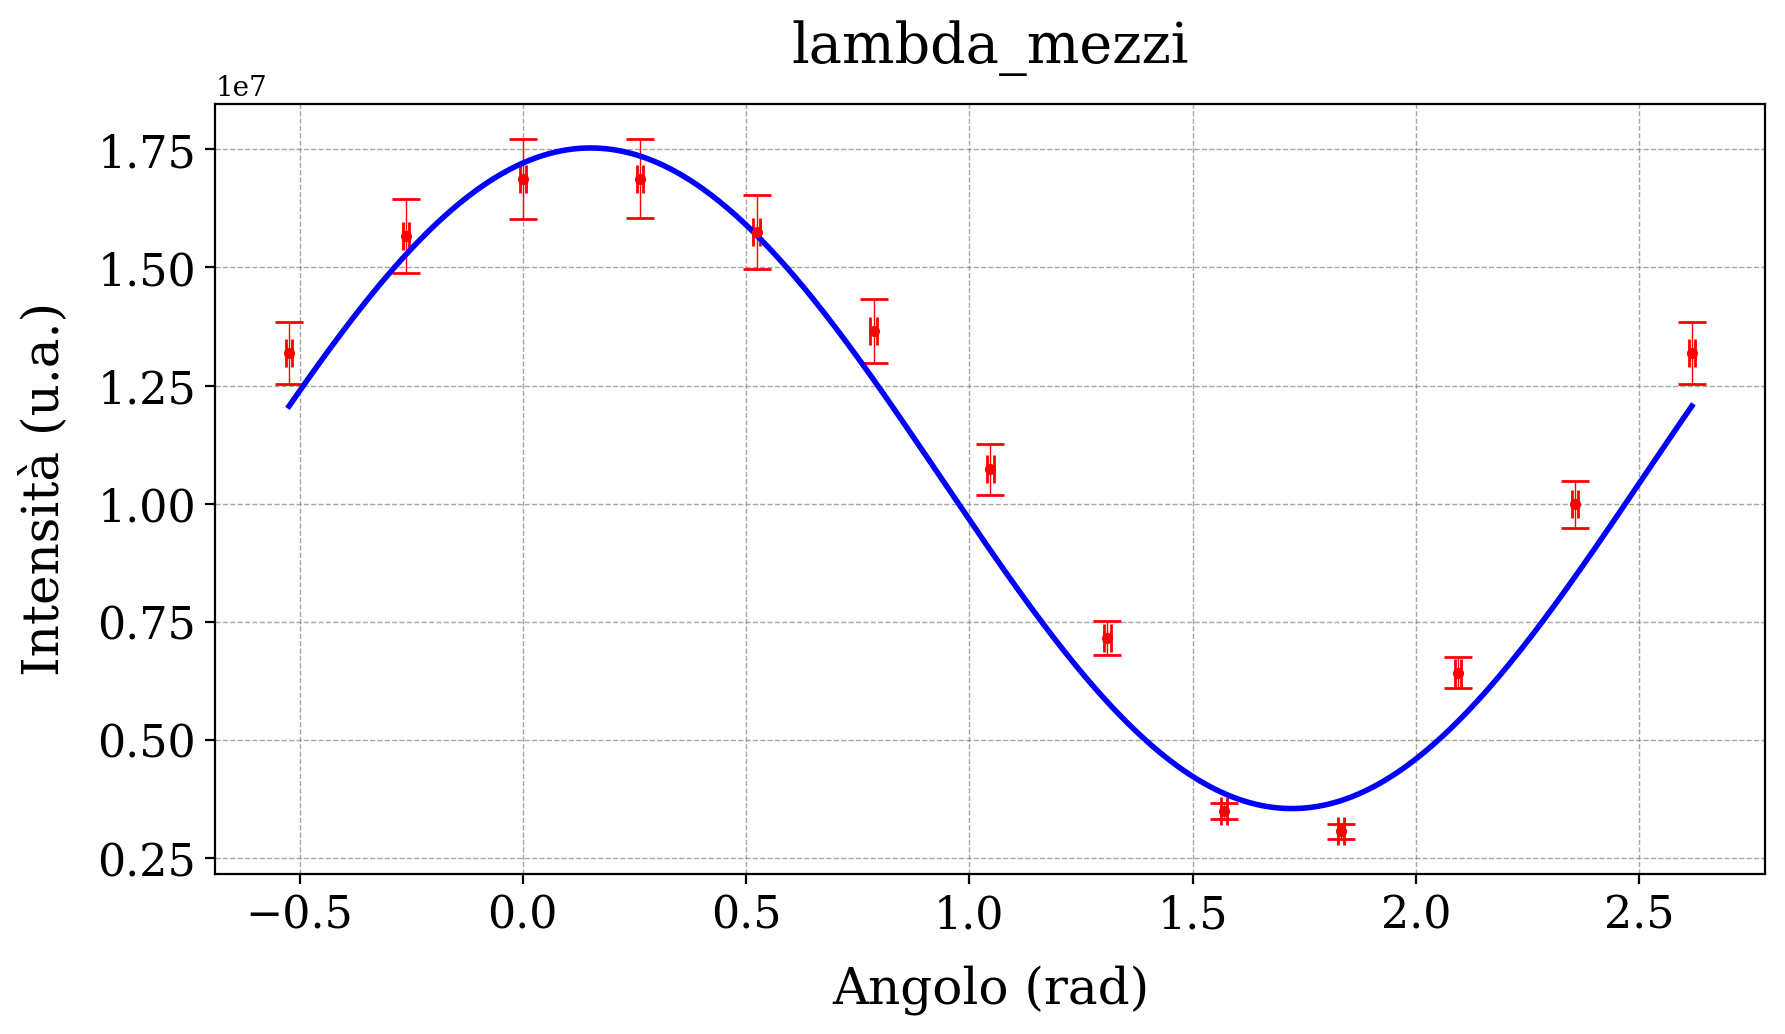

In [51]:
dati = data["malus"]
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
xdata = [dati["angolo"],
         np.full_like(dati["angolo"],2/np.sqrt(24))]
xdata = np.deg2rad(xdata) # Passaggio da gradi a radianti
ydata = [dati["intensita"],
         np.sqrt( err*2 + (0.05*dati["intensita"])**2 )]
gf.parametri_grafico(ax,titolo,xlabel="Angolo (rad)",ylabel="Intensità (u.a.)")
ax.errorbar(xdata[0], ydata[0], xerr=xdata[1], yerr=ydata[1], color="red", fmt=".", **gf.default_error_params())

def malus(par, x):
    I0, theta0, Ibg = par
    return I0 * np.cos(x - theta0)**2 + Ibg
x = xdata[0]
y = ydata[0]
I0_0 = np.max(y) - np.min(y)
theta0_0 = x[np.argmax(y)]
Ibg_0 = np.min(y)
beta0 = [I0_0, theta0_0, Ibg_0]
anal = f.fit(xdata,ydata,malus,beta0,chi=True)

print(f"Fit {titolo}")
print(f"\tA = {gf.formatta_errore(anal[0][0],anal[0][1],txt=True)}")
print(f"\tB = {gf.formatta_errore(anal[1][0],anal[1][1],txt=True)}")
print(f"\tC = {gf.formatta_errore(anal[2][0],anal[2][1],txt=True)}\n")
x = np.linspace(np.min(xdata[0]), np.max(xdata[0]), 500)
y = malus([anal[0][0], anal[1][0], anal[2][0]], x)
ax.plot(x, y, color="blue")